# EEG Seizure Detection: Baseline Models (Task 1)
This notebook focuses on **Task 1: Seizure Detection**. The goal is to develop a system that can accurately identify whether an active seizure (ictal state) is currently occurring based on processed EEG signals. We utilize classic machine learning algorithms to establish performance baselines before moving toward more complex architectures.

**Notebook Workflow**

1. [**Data Loading & Preparation**](#2-data): we import pre-processed features and labels for a specific subject (e.g., `chb04`). Data is loaded from chronological splits to ensure the model is tested on "future" data.
2. [**Baseline Training**](#4-train-baselines): we evaluate 7 different classical models:
    * Linear Models: Logistic Regression, SVM.
    * Probabilistic: Naive Bayes.
    * Distance/Neighbor-based: KNN.
    * Ensemble/Tree-based: Random Forest, XGBoost, LightGBM.
3. [**Handling Imbalance**](#3-helpers): we apply specific class weights and `scale_pos_weight` to address the rarity of seizure events compared to normal activity.
4. [**Hyperparameter Tuning**](#5-hypertune-top-3): we identify the top 3 performing models based on the Validation F1-score and perform an automated search (Randomized/Grid Search) to optimize their settings.
5. [**Performance Evaluation**](#6-results): Models are compared using metrics crucial for medical safety, specifically **F1-score** and **Recall (Sensitivity)**, to ensure we minimize missed seizures.
6. **Pretrained Model exportation**: we exported the best model hypertuned and pretrained on the subject chosed in order to use for further analysis.

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())
sys.path.insert(0, str(proj_dir))

from utils.models.model_classes import (
    LogisticRegressionModel,
    NaiveBayesModel,
    SVMModel,
    RandomForestModel,
    KNNModel,
    XGBModel,
    LGBModel,
)
from utils.model_io import save_model

print("Imports successful")

RANDOM_STATE = 42
N_JOBS = -1

SAVE = True
SAVE_PLOT_PATH = proj_dir / "doc" / "src" / "models"


Imports successful


## 2. Data

Subject `chb04` was chosen as the primary test case due to its balanced data availability, containing both **seizure-containing** and p**urely inter-ictal** files. This ensures a realistic evaluation of the _False Alarm Rate_.

The selected channel was identified via visual inspection as the lead with the highest signal-to-noise ratio and the most prominent electrical signatures during ictal transitions.

In [2]:
SELECTED_SUBJ = "chb04"
SPLIT_PATH = proj_dir / "data" / "split" / "task_1" 
SUBJ_PATH = SPLIT_PATH / SELECTED_SUBJ
SELECTED_FILES = sorted([f.stem for f in SUBJ_PATH.glob("*.npz")]) # ["chb04_08", "chb04_05", "chb04_01", "chb04_02"]
CHANNEL_INDEX = 3
BALANCE_TRAIN = False


def class_counts(y):
    return np.bincount(np.asarray(y).astype(int), minlength=2)


def selected_feature_indices(feature_names, channel_name):
    return [i for i, name in enumerate(feature_names) if str(name).startswith(f"{channel_name}_")]


def make_frame(X, y, feature_names):
    df = pd.DataFrame(X, columns=feature_names)
    df["is_seizure"] = np.asarray(y).astype(int)
    return df


def load_file(file_name, channel_index=CHANNEL_INDEX):
    patient = file_name.split("_")[0]
    data = np.load(SPLIT_PATH / patient / f"{file_name}.npz", allow_pickle=True)
    channel_name = str(data["channels"][channel_index])
    idx = selected_feature_indices(data["feature_names"], channel_name)
    names = data["feature_names"][idx]
    frames = {
        split: make_frame(data[f"X_{split}"][:, idx], data[f"y_{split}"], names)
        for split in ["train", "val", "test"]
    }
    print(f"Loaded {file_name} | channel {channel_index}: {channel_name} | features: {len(idx)}")
    return frames


loaded = [load_file(file_name) for file_name in SELECTED_FILES]
split_frames = {
    split: pd.concat([frames[split] for frames in loaded], ignore_index=True)
    for split in ["train", "val", "test"]
}

if BALANCE_TRAIN:
    pos = split_frames["train"][split_frames["train"]["is_seizure"] == 1]
    neg = split_frames["train"][split_frames["train"]["is_seizure"] == 0].sample(len(pos), random_state=RANDOM_STATE)
    split_frames["train"] = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE)

for split, df in split_frames.items():
    counts = class_counts(df["is_seizure"])
    print(f"{split:5s}: {df.shape} | class distribution: {counts}")
    if np.count_nonzero(counts) < 2:
        print(f"WARNING: {split} contains only one class; ROC-AUC and seizure metrics are not reliable.")


Loaded chb04_01 | channel 3: P7-O1 | features: 18


Loaded chb04_02 | channel 3: P7-O1 | features: 18
Loaded chb04_05 | channel 3: P7-O1 | features: 18
Loaded chb04_08 | channel 3: P7-O1 | features: 18
Loaded chb04_28 | channel 3: P7-O1 | features: 18
train: (11005, 19) | class distribution: [10867   138]
val  : (3498, 19) | class distribution: [3476   22]
test : (4034, 19) | class distribution: [4034    0]


## 3. Helpers

In [3]:
def compute_class_weights(y):
    counts = class_counts(y)
    total = counts.sum()
    return {cls: total / (len(counts) * count) for cls, count in enumerate(counts) if count > 0}


def compute_scale_pos_weight(y):
    counts = class_counts(y)
    return counts[0] / counts[1] if counts[1] > 0 else 1


def positive_scores(model, X):
    if not hasattr(model, "predict_proba"):
        return None
    scores = model.predict_proba(X)
    if getattr(scores, "ndim", 1) == 2:
        return scores[:, 1] if scores.shape[1] > 1 else None
    return scores


def metrics_for(model, df):
    X, y = model.preprocess(df, is_training=False, verbose=True)
    pred = model.predict(X)
    scores = positive_scores(model, X)
    metrics = {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, average="weighted", zero_division=0),
        "recall": recall_score(y, pred, average="weighted", zero_division=0),
        "f1": f1_score(y, pred, average="weighted", zero_division=0),
        "precision_seizure": precision_score(y, pred, pos_label=1, zero_division=0),
        "recall_seizure": recall_score(y, pred, pos_label=1, zero_division=0),
        "f1_seizure": f1_score(y, pred, pos_label=1, zero_division=0),
        "roc_auc": np.nan,
    }
    if scores is not None and len(np.unique(y)) == 2:
        metrics["roc_auc"] = roc_auc_score(y, scores)
    return metrics


def fit_and_score(name, model, results, models):
    X_train, y_train = model.preprocess(split_frames["train"], is_training=True, verbose=True)
    model.train(X_train, y_train)
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row.update({f"train_{k}": v for k, v in metrics_for(model, split_frames["train"]).items()})
    results[name] = row
    models[name] = model
    print(f"{name:20s} | val_f1={row['val_f1']:.4f} | test_f1={row['f1']:.4f} | seizure_recall={row['recall_seizure']:.4f}")


## 4. Train Baselines

In [4]:
class_weights = compute_class_weights(split_frames["train"]["is_seizure"])
scale_pos_weight = compute_scale_pos_weight(split_frames["train"]["is_seizure"])

models = {
    "LogisticRegression": LogisticRegressionModel(class_weight=class_weights, n_jobs=N_JOBS, scaler=None),
    "NaiveBayes": NaiveBayesModel(scaler=None),
    "SVM": SVMModel(class_weight=class_weights, scaler=None),
    "KNN": KNNModel(n_jobs=N_JOBS, scaler=None),
    "RandomForest": RandomForestModel(class_weight=class_weights, n_estimators=200, n_jobs=N_JOBS, scaler=None),
    "XGBoost": XGBModel(
        eval_metric="logloss",
        scaler=None,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        n_jobs=N_JOBS,
    ),
    "LightGBM": LGBModel(class_weight=class_weights, n_estimators=200, verbose=-1, n_jobs=N_JOBS, scaler=None),
}

results = {}
trained_models = {}
for name, model in models.items():
    fit_and_score(name, model, results, trained_models)

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
results_df


[LogisticRegression] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
is_seizure
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[LogisticRegression] Analyzing multicollinearity (threshold=0.95)...
[LogisticRegression] Dropped 2 redundant features. Remaining: 16
[LogisticRegression] Starting training...
[LogisticRegression] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
is_seizure
0    0.993333
1    0.006667
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 features.
[LogisticRegression] Features shape: (1892, 18), Labels shape: (1892,)
Label distribution:
is_seizure
0    0.993658
1    0.006342
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 features.
[LogisticRegression] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
is_seizure
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[LogisticRegression] Applying pre-selected 16 features.
Logi

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,val_f1_seizure,val_roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc
KNN,0.960476,0.987063,0.960476,0.973455,0.014085,0.071429,0.023529,0.579236,0.973044,0.987223,...,0.000000,0.450731,0.930978,0.925703,0.930978,0.912787,0.847458,0.239234,0.373134,0.940334
RandomForest,0.960952,0.989339,0.960952,0.974230,0.064103,0.357143,0.108696,0.708413,0.969873,0.990448,...,0.149254,0.778347,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LightGBM,0.857143,0.988490,0.857143,0.916942,0.016892,0.357143,0.032258,0.726510,0.876850,0.991470,...,0.064257,0.799911,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
NaiveBayes,0.802381,0.988720,0.802381,0.884262,0.014528,0.428571,0.028103,0.703157,0.811311,0.986601,...,0.005571,0.446055,0.886606,0.871740,0.886606,0.878540,0.281046,0.205742,0.237569,0.700499
XGBoost,0.788095,0.989237,0.788095,0.875378,0.015730,0.500000,0.030501,0.780475,0.809197,0.991194,...,0.042440,0.800576,0.987264,0.988909,0.987264,0.987659,0.870833,1.000000,0.930958,0.999929
LogisticRegression,0.548095,0.989933,0.548095,0.701712,0.010471,0.714286,0.020640,0.712676,0.669133,0.991382,...,0.027950,0.762190,0.734182,0.910193,0.734182,0.791245,0.217054,0.803828,0.341811,0.850324
SVM,0.209048,0.991059,0.209048,0.336880,0.007770,0.928571,0.015412,0.648541,0.322410,0.993716,...,0.018377,0.711480,0.378389,0.898282,0.378389,0.466947,0.111905,0.899522,0.199047,0.732950


## 5. Hypertune Top 3

Top 3 by validation F1: ['KNN', 'RandomForest', 'LightGBM']
Hypertuning KNN...
[KNN] Grid Search...

Starting tuning on 4326 samples...

Best parameters found for KNeighborsClassifier:
{'weights': 'uniform', 'n_neighbors': 15, 'metric': 'minkowski'}
[KNN] Train model with best params...
[KNN] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
is_seizure
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[KNN] Analyzing multicollinearity (threshold=0.95)...
[KNN] Dropped 2 redundant features. Remaining: 16
[KNN] Starting training...
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2225
           1       0.33      0.00      0.01       209

    accuracy                           0.91      2434
   macro avg       0.62      0.50      0.48      2434
weighted avg       0.86      0.91      0.87      2434



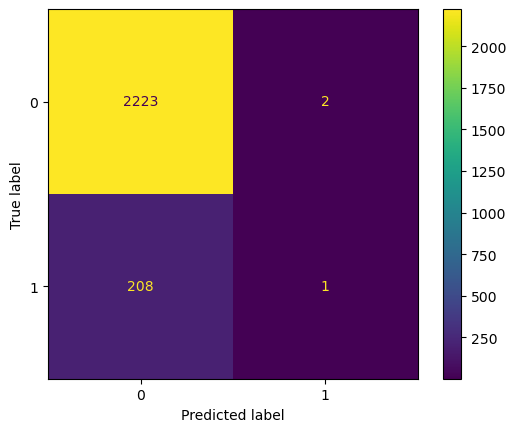

[KNN] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
is_seizure
0    0.993333
1    0.006667
Name: proportion, dtype: float64
[KNN] Applying pre-selected 16 features.
[KNN] Features shape: (1892, 18), Labels shape: (1892,)
Label distribution:
is_seizure
0    0.993658
1    0.006342
Name: proportion, dtype: float64
[KNN] Applying pre-selected 16 features.
Hypertuning RandomForest...
[RandomForest] Grid Search...

Best parameters found for RandomForestClassifier:
{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 30}
[RandomForest] Train model with best params...
[RandomForest] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[RandomForest] Starting training...
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2225
           1       0.91      0.99      0.95       209

    accuracy                           0.99      2434


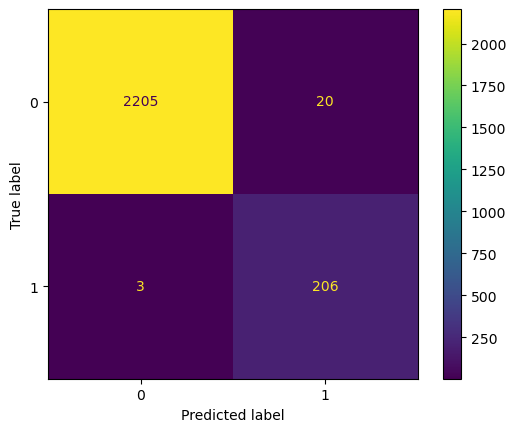

[RandomForest] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
0    0.993333
1    0.006667
Name: proportion, dtype: float64
[RandomForest] Features shape: (1892, 18), Labels shape: (1892,)
Label distribution:
0    0.993658
1    0.006342
Name: proportion, dtype: float64
Hypertuning LightGBM...
[LGBM] Starting Randomized Search...

Best parameters found for LGBMClassifier:
{'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best params: {'num_leaves': 63, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1}
[LGBM] Best validation score: 1.0000
[LGBM] Train model with best params...
[LGBM] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
is_seizure
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[LGBM] Starting training...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2225
           1       1.00      1.00      1.00       209

 

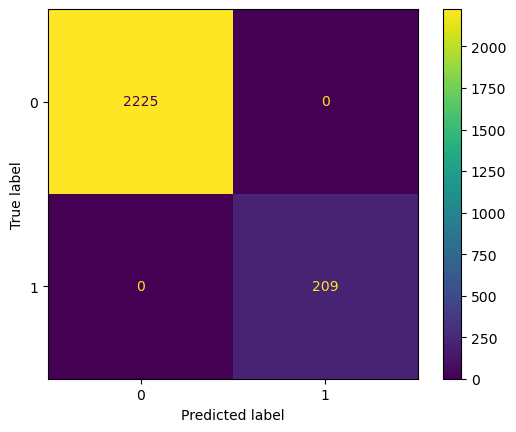

[LGBM] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
is_seizure
0    0.993333
1    0.006667
Name: proportion, dtype: float64
[LGBM] Features shape: (1892, 18), Labels shape: (1892,)
Label distribution:
is_seizure
0    0.993658
1    0.006342
Name: proportion, dtype: float64


,best_params,search_val_f1,val_f1,f1,f1_seizure,roc_auc
KNN_tuned,"{'weights': 'uniform', 'n_neighbors': 15, 'met...",0.989968,0.989703,0.989773,0.0,0.61584
RandomForest_tuned,"{'min_samples_split': 10, 'min_samples_leaf': ...",1.0,0.941385,0.922429,0.034483,0.707472
LightGBM_tuned,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0,0.929775,0.92161,0.03413,0.726442


In [5]:
param_grids = {
    "LogisticRegression": {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["lbfgs", "liblinear"]},
    "NaiveBayes": {"var_smoothing": np.logspace(-12, -6, 7)},
    "SVM": {"C": [0.1, 1.0, 10.0], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]},
    "KNN": {"n_neighbors": [3, 5, 7, 11, 15], "weights": ["uniform", "distance"], "metric": ["minkowski", "manhattan"]},
    "RandomForest": {"max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    "XGBoost": {"max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
    "LightGBM": {"max_depth": [-1, 5, 10, 20], "learning_rate": [0.01, 0.05, 0.1], "num_leaves": [15, 31, 63], "min_child_samples": [10, 20, 50]},
}

top3 = [name for name in results_df.index if name in param_grids][:3]
tuning_rows = {}
print(f"Top 3 by validation F1: {top3}")

for name in top3:
    print(f"Hypertuning {name}...")
    model = trained_models[name]
    search = model.hypertune_pipeline(
        split_frames["train"],
        split_frames["val"],
        param_grids[name],
        n_iter=12,
        scoring="f1_weighted",
        verbose=False,
    )
    tuned_name = f"{name}_tuned"
    row = metrics_for(model, split_frames["test"])
    row.update({f"val_{k}": v for k, v in metrics_for(model, split_frames["val"]).items()})
    row["best_params"] = search.best_params_
    row["search_val_f1"] = search.best_score_
    results[tuned_name] = row
    trained_models[tuned_name] = model
    tuning_rows[tuned_name] = row

results_df = pd.DataFrame(results).T.sort_values("val_f1", ascending=False)
pd.DataFrame(tuning_rows).T[["best_params", "search_val_f1", "val_f1", "f1", "f1_seizure", "roc_auc"]]


## 6. Results

,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc,val_accuracy,val_precision,...,train_accuracy,train_precision,train_recall,train_f1,train_precision_seizure,train_recall_seizure,train_f1_seizure,train_roc_auc,best_params,search_val_f1
KNN_tuned,0.992857,0.986708,0.992857,0.989773,0.0,0.0,0.0,0.61584,0.992072,0.987345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'weights': 'uniform', 'n_neighbors': 15, 'met...",0.989968
KNN,0.960476,0.987063,0.960476,0.973455,0.014085,0.071429,0.023529,0.579236,0.973044,0.987223,...,0.930978,0.925703,0.930978,0.912787,0.847458,0.239234,0.373134,0.940334,NaN,NaN
RandomForest,0.960952,0.989339,0.960952,0.97423,0.064103,0.357143,0.108696,0.708413,0.969873,0.990448,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
RandomForest_tuned,0.866667,0.988553,0.866667,0.922429,0.018116,0.357143,0.034483,0.707472,0.899577,0.991578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'min_samples_split': 10, 'min_samples_leaf': ...",1.0
LightGBM_tuned,0.865238,0.988543,0.865238,0.92161,0.017921,0.357143,0.03413,0.726442,0.878964,0.991479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'num_leaves': 63, 'min_child_samples': 20, 'm...",1.0
LightGBM,0.857143,0.98849,0.857143,0.916942,0.016892,0.357143,0.032258,0.72651,0.87685,0.99147,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
NaiveBayes,0.802381,0.98872,0.802381,0.884262,0.014528,0.428571,0.028103,0.703157,0.811311,0.986601,...,0.886606,0.87174,0.886606,0.87854,0.281046,0.205742,0.237569,0.700499,NaN,NaN
XGBoost,0.788095,0.989237,0.788095,0.875378,0.01573,0.5,0.030501,0.780475,0.809197,0.991194,...,0.987264,0.988909,0.987264,0.987659,0.870833,1.0,0.930958,0.999929,NaN,NaN
LogisticRegression,0.548095,0.989933,0.548095,0.701712,0.010471,0.714286,0.02064,0.712676,0.669133,0.991382,...,0.734182,0.910193,0.734182,0.791245,0.217054,0.803828,0.341811,0.850324,NaN,NaN
SVM,0.209048,0.991059,0.209048,0.33688,0.00777,0.928571,0.015412,0.648541,0.32241,0.993716,...,0.378389,0.898282,0.378389,0.466947,0.111905,0.899522,0.199047,0.73295,NaN,NaN


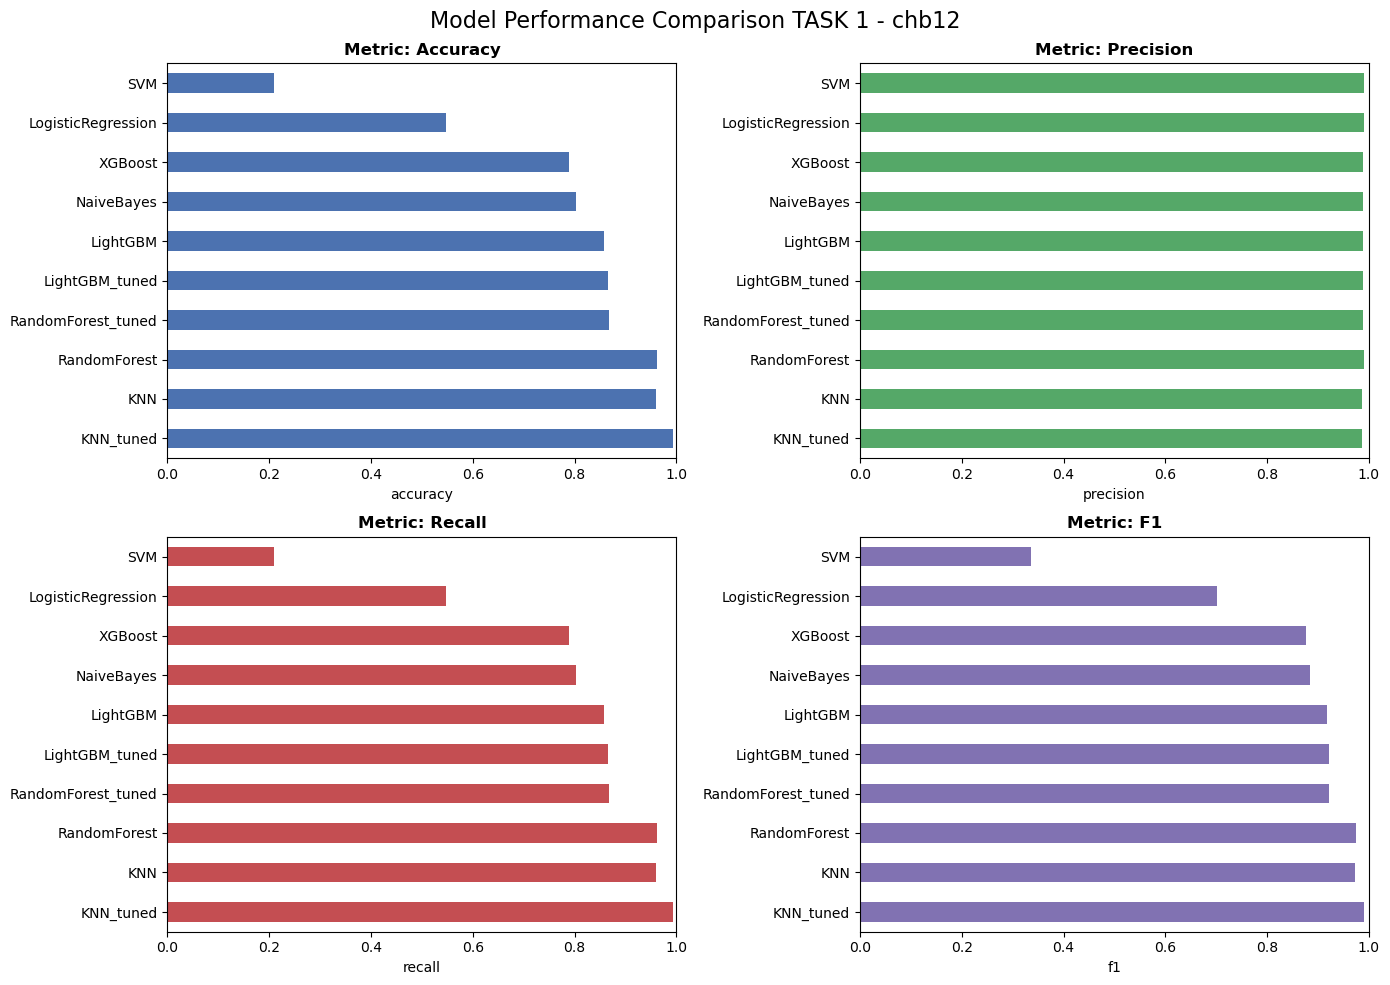

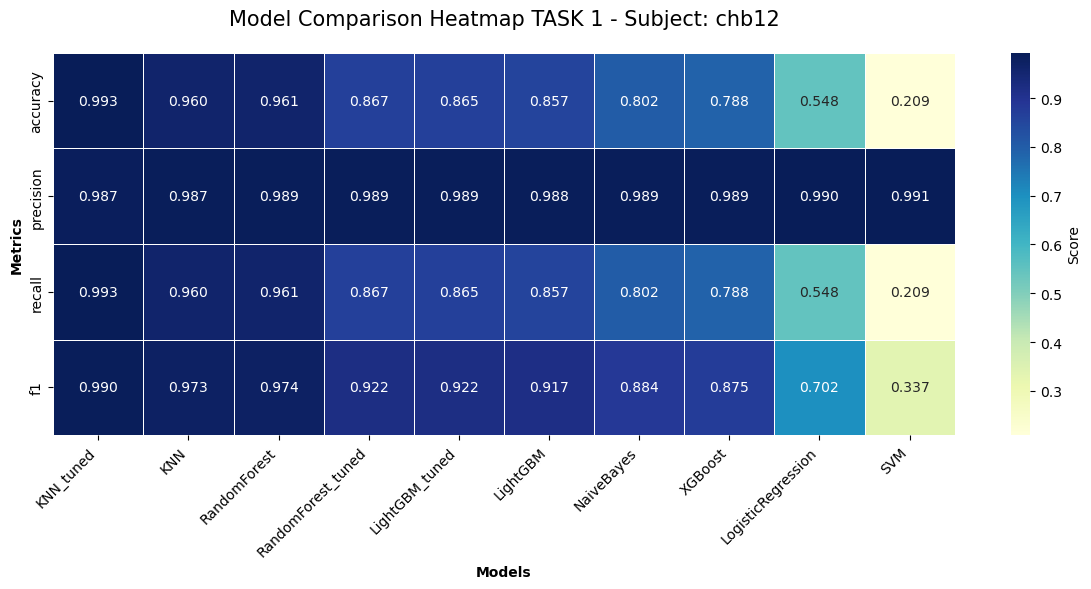

Best model by validation F1: KNN_tuned
accuracy                                                            0.992857
precision                                                           0.986708
recall                                                              0.992857
f1                                                                  0.989773
precision_seizure                                                        0.0
recall_seizure                                                           0.0
f1_seizure                                                               0.0
roc_auc                                                              0.61584
val_accuracy                                                        0.992072
val_precision                                                       0.987345
val_recall                                                          0.992072
val_f1                                                              0.989703
val_precision_seizure                

In [6]:
display(results_df)

metrics = ["accuracy", "precision", "recall", "f1"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Model Performance Comparison TASK 1 - {SELECTED_SUBJ}", fontsize=16)
for metric, color, ax in zip(metrics, colors, axes.flatten()):
    # sorted_series = results_df[metric].astype(float).sort_values()
    results_df[metric].astype(float).plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Metric: {metric.capitalize()}", fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task1_barchart_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

# heatmap
heatmap_data = results_df[metrics].astype(float).T

fig = plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5,cbar_kws={'label': 'Score'}
)

plt.title(f"Model Comparison Heatmap TASK 1 - Subject: {SELECTED_SUBJ}", fontsize=15, pad=20)
plt.xlabel("Models", fontweight='bold')
plt.ylabel("Metrics", fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

if SAVE:
    SAVE_PLOT_PATH.mkdir(parents=True, exist_ok=True)
    plot_file = SAVE_PLOT_PATH / f"task1_heatmap_metrics_comparison_{SELECTED_SUBJ}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches='tight')

best_model_name = results_df["val_f1"].idxmax()
print(f"Best model by validation F1: {best_model_name}")
print(results_df.loc[best_model_name])


## Prediction on Test split of the best model

Test metrics for KNN before tuning:
{'val_accuracy': 0.9730443974630021, 'val_precision': 0.9872225942959761, 'val_recall': 0.9730443974630021, 'val_f1': 0.9800822219289815, 'val_precision_seizure': 0.0, 'val_recall_seizure': 0.0, 'val_f1_seizure': 0.0, 'val_roc_auc': 0.4507313829787234}
Test metrics for KNN_tuned after tuning:
{'val_accuracy': 0.9920718816067653, 'val_precision': 0.9873452289151502, 'val_recall': 0.9920718816067653, 'val_f1': 0.9897029118709041, 'val_precision_seizure': 0.0, 'val_recall_seizure': 0.0, 'val_f1_seizure': 0.0, 'val_roc_auc': 0.5068262411347517}
--------------------------------------------------
[KNN] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
is_seizure
0    0.993333
1    0.006667
Name: proportion, dtype: float64
[KNN] Applying pre-selected 16 features.
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2086
           1       0.00      0.00      0.00        14

    accuracy 

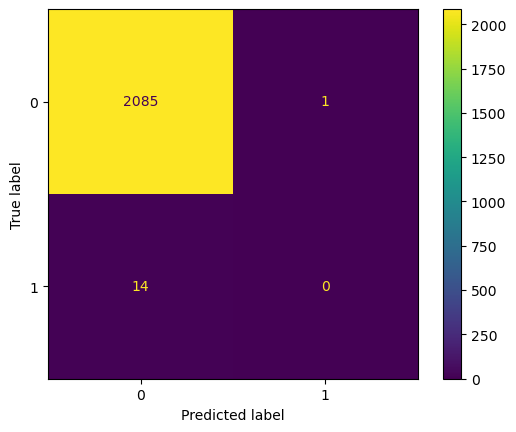

Test metrics for RandomForest before tuning:
{'val_accuracy': 0.9698731501057083, 'val_precision': 0.9904477034783018, 'val_recall': 0.9698731501057083, 'val_f1': 0.9793664605729625, 'val_precision_seizure': 0.09090909090909091, 'val_recall_seizure': 0.4166666666666667, 'val_f1_seizure': 0.14925373134328357, 'val_roc_auc': 0.7783466312056737}
Test metrics for RandomForest_tuned after tuning:
{'val_accuracy': 0.8995771670190275, 'val_precision': 0.9915782799508812, 'val_recall': 0.8995771670190275, 'val_f1': 0.941384635455966, 'val_precision_seizure': 0.041237113402061855, 'val_recall_seizure': 0.6666666666666666, 'val_f1_seizure': 0.07766990291262135, 'val_roc_auc': 0.761790780141844}
--------------------------------------------------
[RandomForest] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
0    0.993333
1    0.006667
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      2086


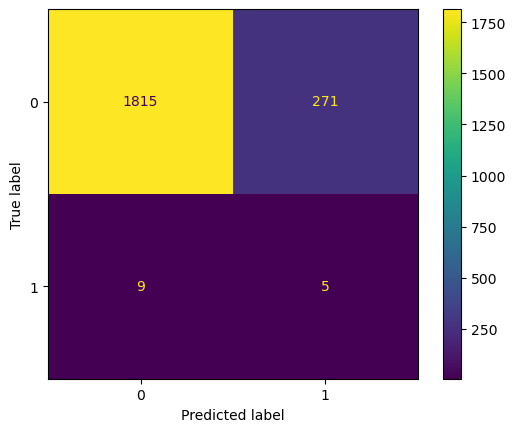

Test metrics for LightGBM before tuning:
{'val_accuracy': 0.8768498942917548, 'val_precision': 0.9914700087973644, 'val_recall': 0.8768498942917548, 'val_f1': 0.9285707980796879, 'val_precision_seizure': 0.03375527426160337, 'val_recall_seizure': 0.6666666666666666, 'val_f1_seizure': 0.0642570281124498, 'val_roc_auc': 0.7999113475177305}
Test metrics for LightGBM_tuned after tuning:
{'val_accuracy': 0.8789640591966174, 'val_precision': 0.9914794746576386, 'val_recall': 0.8789640591966174, 'val_f1': 0.9297745717767891, 'val_precision_seizure': 0.034334763948497854, 'val_recall_seizure': 0.6666666666666666, 'val_f1_seizure': 0.0653061224489796, 'val_roc_auc': 0.7963652482269503}
--------------------------------------------------
[LGBM] Features shape: (2100, 18), Labels shape: (2100,)
Label distribution:
is_seizure
0    0.993333
1    0.006667
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      2086
     

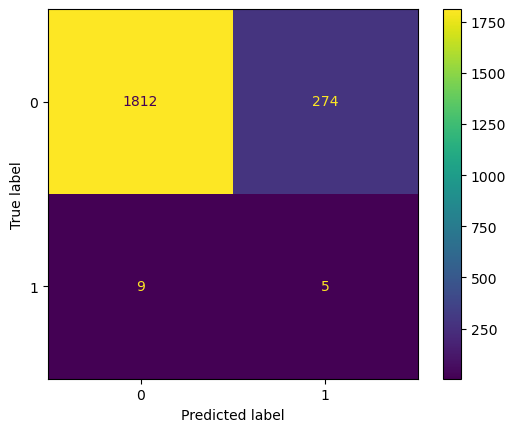

In [7]:
for name in top3:
    print(f"Test metrics for {name} before tuning:")
    print({k: v for k, v in results[name].items() if k.startswith("test_") or k.startswith("val_")})
    tuned_name = f"{name}_tuned"
    print(f"Test metrics for {tuned_name} after tuning:")
    print({k: v for k, v in results[tuned_name].items() if k.startswith("test_") or k.startswith("val_")})
    print("-" * 50)
    model = trained_models[tuned_name]
    model.test_pipeline(split_frames["test"], verbose=True)

[KNN] Grid Search...

Starting tuning on 4326 samples...
Fitting 1 folds for each of 12 candidates, totalling 12 fits

Best parameters found for KNeighborsClassifier:
{'weights': 'uniform', 'n_neighbors': 15, 'metric': 'minkowski'}
[KNN] Train model with best params...
[KNN] Features shape: (2434, 18), Labels shape: (2434,)
Label distribution:
is_seizure
0    0.914133
1    0.085867
Name: proportion, dtype: float64
[KNN] Analyzing multicollinearity (threshold=0.95)...
[KNN] Dropped 2 redundant features. Remaining: 16
[KNN] Starting training...
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2225
           1       0.33      0.00      0.01       209

    accuracy                           0.91      2434
   macro avg       0.62      0.50      0.48      2434
weighted avg       0.86      0.91      0.87      2434



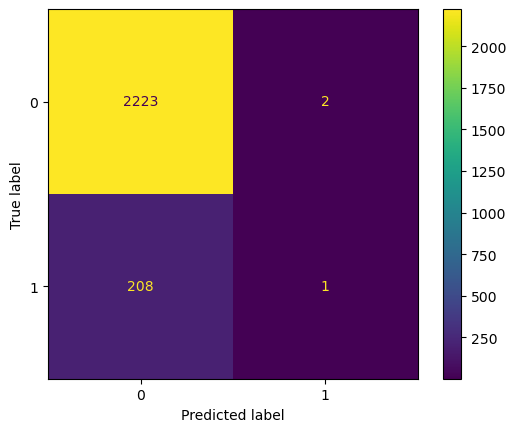

In [8]:
model = trained_models['KNN']
search = model.hypertune_pipeline(
            split_frames["train"],
            split_frames["val"],
            param_grids["KNN"],
            n_iter=12,
            scoring="f1_weighted",
            verbose=True,
            model_name='KNN',
        )


## 7. Save Best Trained Model

The best model is selected according to validation F1-score and exported with the subject identifier in the filename. Saving the trained object makes it available for later comparison, reporting, or deployment-oriented analysis without retraining the notebook.

In [9]:
best_model_name = results_df["val_f1"].idxmax()
best_model = trained_models[best_model_name]

saved_model_path = save_model(
    best_model,
    filename=f"{SELECTED_SUBJ}_{best_model_name}_best_model",
    models_dir=proj_dir / "saved_models" / "task_1",
)
print(f"Saved best model ({best_model_name}) to: {saved_model_path}")


Saved best model (KNN) to: C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\saved_models\task_1\chb04_KNN_best_model.joblib
